In [98]:
import pandas as pd

df = pd.read_csv('Reddit_TV_Discussions.csv')
df.head(10)

,Unnamed: 0,title,type,year,post
0,0,Better Call Saul,linear,2017,Walter. And there the chain ends.
1,1,Better Call Saul,linear,2016,"I love this show. But it's hard to argue against its pace. It's sooooooooooo slooooowww. The writing, the acting, the direction, the production, all of it top notch. That however, doesn't mean we can't complain it's ""boring"". It's a different kind of boring, but I totally get the critique and I feel the same way. The story takes way too long to develop. It's great to have slower paced TV, but I think this show over does it. \n\nI think it'd be less of a problem if we didn't get only 10 episodes. It feels like you get these two and a half months a year, and then nothing, and overall nothing much happened, and that's a bit frustrating. \n\nIn the end though, the show can be all those good things whilst also being possible to criticize it for how slow it is. I think it falls short of its own potential due to just that."
2,2,Better Call Saul,linear,2017,What am I missing? A lot of reference to ribs on a burger.....Is this from a Carls Jr./Hardee's commercial or something?
3,3,Better Call Saul,linear,2018,"Oh come on Mike, he's a good little boy."
4,4,Better Call Saul,linear,2017,Look again 👀
5,5,Better Call Saul,linear,2018,"I'm watching with my mum and she was like ""Kim is kinda boring, ya know they haven't given her much to do especially so far."" Then the scene with Howard happened and she said ""Well there ya go!""."
6,6,Better Call Saul,linear,2020,"Maybe when Jimmy gets the $7 million to ABQ, they learn that cash can't be used to bail out Lalo. Lalo then forces Jimmy to get his wife to use her good client, Mesa Verde, to launder it for him. Kim gets caught and has to disappear. Mike knows a guy, or he thinks he can find one. He implied that with Nacho."
7,7,Better Call Saul,linear,2016,Didn't VG say no other BB characters would be introduced in the foreseeable future?
8,8,Better Call Saul,linear,2017,"I remember spooning (gahhk that word is so bad) with my ex and falling asleep. As I slept, my face slowly slid along the pillow and my eye socket touched her hair. I felt then like I was speeding down a tunnel and that I erupted out of the tunnel into a brief moment of immense discomfort (hair on your eye socket is a weird sort of tickle), jolting awake in fear and scaring the shit out of her."
9,9,Better Call Saul,linear,2018,How did Gus find out mike knew about Nacho?


In [99]:
# Delete Unnamed: 0
df = df.drop(columns=['Unnamed: 0'])
df.head(10)

,title,type,year,post
0,Better Call Saul,linear,2017,Walter. And there the chain ends.
1,Better Call Saul,linear,2016,"I love this show. But it's hard to argue against its pace. It's sooooooooooo slooooowww. The writing, the acting, the direction, the production, all of it top notch. That however, doesn't mean we can't complain it's ""boring"". It's a different kind of boring, but I totally get the critique and I feel the same way. The story takes way too long to develop. It's great to have slower paced TV, but I think this show over does it. \n\nI think it'd be less of a problem if we didn't get only 10 episodes. It feels like you get these two and a half months a year, and then nothing, and overall nothing much happened, and that's a bit frustrating. \n\nIn the end though, the show can be all those good things whilst also being possible to criticize it for how slow it is. I think it falls short of its own potential due to just that."
2,Better Call Saul,linear,2017,What am I missing? A lot of reference to ribs on a burger.....Is this from a Carls Jr./Hardee's commercial or something?
3,Better Call Saul,linear,2018,"Oh come on Mike, he's a good little boy."
4,Better Call Saul,linear,2017,Look again 👀
5,Better Call Saul,linear,2018,"I'm watching with my mum and she was like ""Kim is kinda boring, ya know they haven't given her much to do especially so far."" Then the scene with Howard happened and she said ""Well there ya go!""."
6,Better Call Saul,linear,2020,"Maybe when Jimmy gets the $7 million to ABQ, they learn that cash can't be used to bail out Lalo. Lalo then forces Jimmy to get his wife to use her good client, Mesa Verde, to launder it for him. Kim gets caught and has to disappear. Mike knows a guy, or he thinks he can find one. He implied that with Nacho."
7,Better Call Saul,linear,2016,Didn't VG say no other BB characters would be introduced in the foreseeable future?
8,Better Call Saul,linear,2017,"I remember spooning (gahhk that word is so bad) with my ex and falling asleep. As I slept, my face slowly slid along the pillow and my eye socket touched her hair. I felt then like I was speeding down a tunnel and that I erupted out of the tunnel into a brief moment of immense discomfort (hair on your eye socket is a weird sort of tickle), jolting awake in fear and scaring the shit out of her."
9,Better Call Saul,linear,2018,How did Gus find out mike knew about Nacho?


In [100]:
df.dtypes

title    object
type     object
year      int64
post     object
dtype: object

In [101]:
titles = df['title'].unique()
print(titles)
print(len(titles))

['Better Call Saul' 'Black Mirror' 'Breaking Bad' 'Dark' 'Fargo'
 'Game of Thrones' 'House of Cards' 'La Casa de Papel' 'Mindhunter'
 'Mr. Robot' 'Orange is the New Black' 'Ozark' 'Stranger Things'
 'Succession' 'The Crown' 'The Mandelorian' 'The Newsroom' 'The Witcher'
 'True Detective' 'Twin Peaks']
20


We kunnen misschien onderzoeken of bepaalde films (better call saul bijvoorbeeld) betere posts/reviews krijgen naarmate we verder de tijd in gaan.

Does the sentiment of online posts about (movie/show title) change over time?

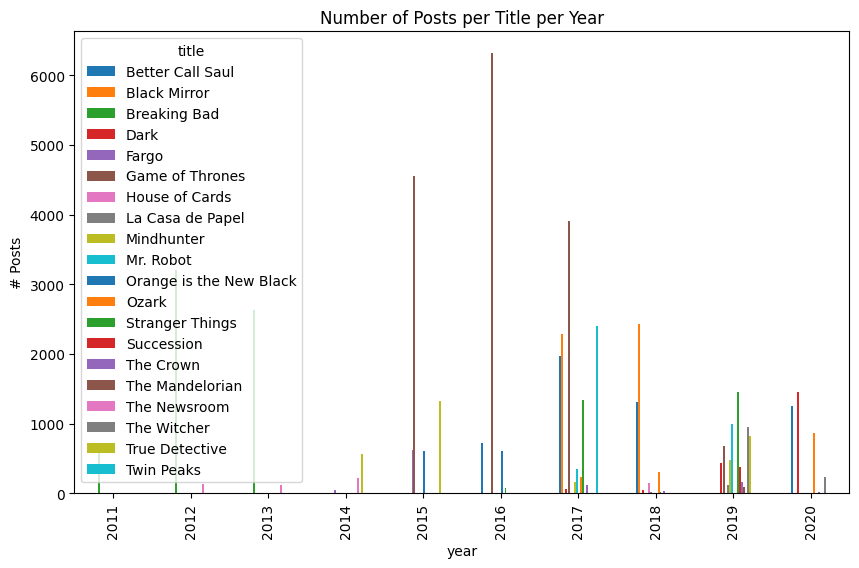

In [102]:
import matplotlib.pyplot as plt

posts = df.groupby(['year', 'title']).size().unstack(fill_value=0)

posts.plot(kind='bar', figsize=(10,6))
plt.ylabel('# Posts')
plt.title('Number of Posts per Title per Year')
plt.show()

In [103]:
new = df.groupby(['title', 'year'])['year'].count()
new.loc['Better Call Saul']

year
2016     731
2017    1971
2018    1307
2020    1259
Name: year, dtype: int64

In [104]:
new.loc['Game of Thrones']

year
2015    4559
2016    6313
2017    3903
2019     687
Name: year, dtype: int64

In [105]:
# Filter df to titles we want to use for research
df1 = df[df['title'].isin(["Better Call Saul", "Game of Thrones"])].copy()
# Check if works
print(df1['title'].unique())

['Better Call Saul' 'Game of Thrones']


In [106]:
import re
import html

# Source: https://docs.python.org/3/library/re.html
def clean_post(post):
  if not isinstance(post, str):
    return " "

  # Remove URL
  post = re.sub(r'https?://[^\s\)\]\}]+|www\.[^\s\)\]\}]+', " ", post)
  # Decode HTML entities (double-encoding)
  post = html.unescape(html.unescape(post))
  # KEEP spaces: normalize whitespace instead of deleting it
  post = re.sub(r'\s+', ' ', post).strip()

  return(post)

df1['post_clean'] = df1['post'].apply(clean_post)

108 rows of empty fields because original post contain links for example. There is no textual sentiment information so these rows will be deleted

In [107]:
pd.set_option('display.max_colwidth', None)

# Check for length < 3
df1[df1['post_clean'].str.len() < 3]

,title,type,year,post,post_clean
106,Better Call Saul,linear,2017,?,?
418,Better Call Saul,linear,2020,https://knowyourmeme.com/memes/this-isnt-even-my-final-form,
783,Better Call Saul,linear,2020,https://i.imgur.com/y7PK25K.png,
828,Better Call Saul,linear,2017,https://www.reddit.com/r/betterCallSaul/comments/6gx7g9/better_call_saul_s03e09_fall_postepisode/ditv1ho/,
1094,Better Call Saul,linear,2017,https://pbs.twimg.com/media/C-yjhFWXoAAus1K.jpg,
...,...,...,...,...,...
32607,Game of Thrones,linear,2016,http://i.imgur.com/7SghPI0.jpg,
32911,Game of Thrones,linear,2019,https://i.imgur.com/nLYEmSd.jpg,
32948,Game of Thrones,linear,2015,http://awoiaf.westeros.org/index.php/Valyrian_steel#List_of_known_Valyrian_steel_blades,
32962,Game of Thrones,linear,2019,https://media.giphy.com/media/3FBwwRCNTSa52/giphy.gif,


In [108]:
# Remove rows with length < 3 (makes sure there are no empty column values)
df1 = df1[df1['post_clean'].str.len() >= 3]

In [109]:
df1.shape

(20622, 5)

In [110]:
# Drop exact duplicates (within title)
df1 = df1.drop_duplicates(subset=['title', 'post_clean'])

In [111]:
df1.shape

(19425, 5)

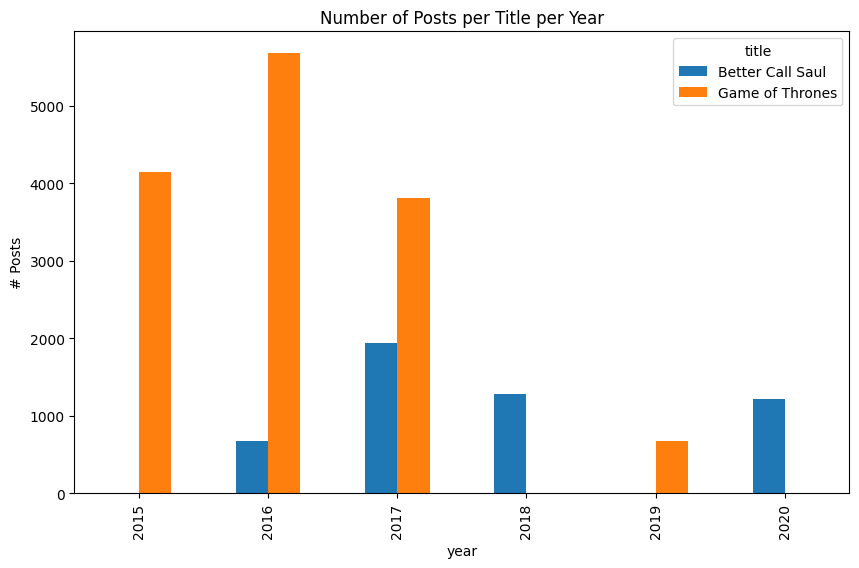

In [112]:
posts1 = df1.groupby(['year', 'title']).size().unstack(fill_value=0)

posts1.plot(kind='bar', figsize=(10,6))
plt.ylabel('# Posts')
plt.title('Number of Posts per Title per Year')
plt.show()

In [113]:
df1.to_csv('Reddit_Data.csv', index=False)

In [114]:
display(df1.head(10))

,title,type,year,post,post_clean
0,Better Call Saul,linear,2017,Walter. And there the chain ends.,Walter. And there the chain ends.
1,Better Call Saul,linear,2016,"I love this show. But it's hard to argue against its pace. It's sooooooooooo slooooowww. The writing, the acting, the direction, the production, all of it top notch. That however, doesn't mean we can't complain it's ""boring"". It's a different kind of boring, but I totally get the critique and I feel the same way. The story takes way too long to develop. It's great to have slower paced TV, but I think this show over does it. \n\nI think it'd be less of a problem if we didn't get only 10 episodes. It feels like you get these two and a half months a year, and then nothing, and overall nothing much happened, and that's a bit frustrating. \n\nIn the end though, the show can be all those good things whilst also being possible to criticize it for how slow it is. I think it falls short of its own potential due to just that.","I love this show. But it's hard to argue against its pace. It's sooooooooooo slooooowww. The writing, the acting, the direction, the production, all of it top notch. That however, doesn't mean we can't complain it's ""boring"". It's a different kind of boring, but I totally get the critique and I feel the same way. The story takes way too long to develop. It's great to have slower paced TV, but I think this show over does it. I think it'd be less of a problem if we didn't get only 10 episodes. It feels like you get these two and a half months a year, and then nothing, and overall nothing much happened, and that's a bit frustrating. In the end though, the show can be all those good things whilst also being possible to criticize it for how slow it is. I think it falls short of its own potential due to just that."
2,Better Call Saul,linear,2017,What am I missing? A lot of reference to ribs on a burger.....Is this from a Carls Jr./Hardee's commercial or something?,What am I missing? A lot of reference to ribs on a burger.....Is this from a Carls Jr./Hardee's commercial or something?
3,Better Call Saul,linear,2018,"Oh come on Mike, he's a good little boy.","Oh come on Mike, he's a good little boy."
4,Better Call Saul,linear,2017,Look again 👀,Look again 👀
5,Better Call Saul,linear,2018,"I'm watching with my mum and she was like ""Kim is kinda boring, ya know they haven't given her much to do especially so far."" Then the scene with Howard happened and she said ""Well there ya go!"".","I'm watching with my mum and she was like ""Kim is kinda boring, ya know they haven't given her much to do especially so far."" Then the scene with Howard happened and she said ""Well there ya go!""."
6,Better Call Saul,linear,2020,"Maybe when Jimmy gets the $7 million to ABQ, they learn that cash can't be used to bail out Lalo. Lalo then forces Jimmy to get his wife to use her good client, Mesa Verde, to launder it for him. Kim gets caught and has to disappear. Mike knows a guy, or he thinks he can find one. He implied that with Nacho.","Maybe when Jimmy gets the $7 million to ABQ, they learn that cash can't be used to bail out Lalo. Lalo then forces Jimmy to get his wife to use her good client, Mesa Verde, to launder it for him. Kim gets caught and has to disappear. Mike knows a guy, or he thinks he can find one. He implied that with Nacho."
7,Better Call Saul,linear,2016,Didn't VG say no other BB characters would be introduced in the foreseeable future?,Didn't VG say no other BB characters would be introduced in the foreseeable future?
8,Better Call Saul,linear,2017,"I remember spooning (gahhk that word is so bad) with my ex and falling asleep. As I slept, my face slowly slid along the pillow and my eye socket touched her hair. I felt then like I was speeding down a tunnel and that I erupted out of the tunnel into a brief moment of immense discomfort (hair on your eye socket is a weird sort of tickle), jolting awake in fear and scaring the shit out of her.","I remember spo

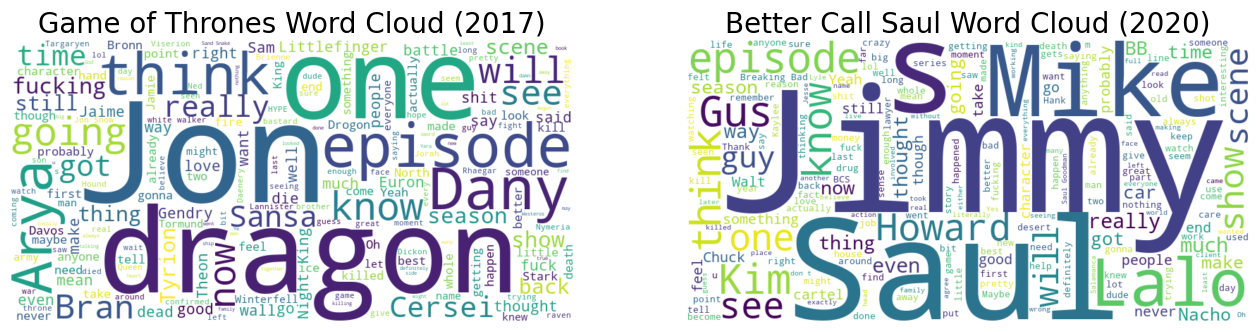

In [115]:
# Create word clouds for each serie: Game of Thrones and Better Call Saul
from wordcloud import WordCloud
import matplotlib.pyplot as plt 

# Combine all posts for each title
posts_got = ' '.join(df1[(df1['title'] == 'Game of Thrones') & (df1['year'] == 2017)]['post_clean'].tolist())
posts_bcs = ' '.join(df1[(df1['title'] == 'Better Call Saul') & (df1['year'] == 2020)]['post_clean'].tolist())

# Generate word clouds
wordcloud_got = WordCloud(width=800, height=400, background_color='white').generate(posts_got)
wordcloud_bcs = WordCloud(width=800, height=400, background_color='white').generate(posts_bcs)

# Plot word clouds
plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plt.imshow(wordcloud_got, interpolation='bilinear')
plt.title('Game of Thrones Word Cloud (2017)', fontsize=20)
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(wordcloud_bcs, interpolation='bilinear')
plt.title('Better Call Saul Word Cloud (2020)', fontsize=20)
plt.axis('off')
plt.show()


The second wordcloud produces a one letter word "S". This should be added on the stopword list to be removed.

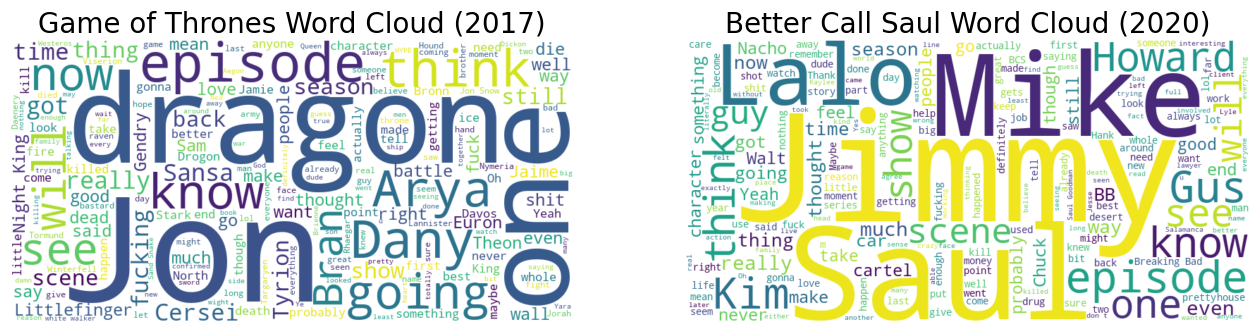

In [116]:
# Import stopwords and add custom stopwords for the letter S
from wordcloud import WordCloud, STOPWORDS

custom_stopwords = STOPWORDS.union({"s"})

wordcloud_got = WordCloud(
    width=800,
    height=400,
    background_color='white',
    stopwords=custom_stopwords
).generate(posts_got)

wordcloud_bcs = WordCloud(
    width=800,
    height=400,
    background_color='white',
    stopwords=custom_stopwords
).generate(posts_bcs)

# Plot word clouds
plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plt.imshow(wordcloud_got, interpolation='bilinear')
plt.title('Game of Thrones Word Cloud (2017)', fontsize=20)
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(wordcloud_bcs, interpolation='bilinear')
plt.title('Better Call Saul Word Cloud (2020)', fontsize=20)
plt.axis('off')
plt.show()


### Insights based on the Wordcloud

We can clearly see that in both shows that characters are more dicussed
Also the word One is shown quite frequently on both shows. This will be further researched, in which context one relate to as this could maybe be about episode or season 1.


In [117]:
# Find post that contains the word 'one' in it
df1[df1['post_clean'].str.contains(r'\bone\b', case=False, na=False)]

,title,type,year,post,post_clean
6,Better Call Saul,linear,2020,"Maybe when Jimmy gets the $7 million to ABQ, they learn that cash can't be used to bail out Lalo. Lalo then forces Jimmy to get his wife to use her good client, Mesa Verde, to launder it for him. Kim gets caught and has to disappear. Mike knows a guy, or he thinks he can find one. He implied that with Nacho.","Maybe when Jimmy gets the $7 million to ABQ, they learn that cash can't be used to bail out Lalo. Lalo then forces Jimmy to get his wife to use her good client, Mesa Verde, to launder it for him. Kim gets caught and has to disappear. Mike knows a guy, or he thinks he can find one. He implied that with Nacho."
29,Better Call Saul,linear,2017,"I don't think Nacho got the brains needed to make one. Huh...maybe he will ask Saul, who will ask Mike, who will ask Gus, who will ask Gale (if he will appear of course)...huh...","I don't think Nacho got the brains needed to make one. Huh...maybe he will ask Saul, who will ask Mike, who will ask Gus, who will ask Gale (if he will appear of course)...huh..."
36,Better Call Saul,linear,2018,Nobody else have one of *those* boxes? Where you keep all the really important stuff.,Nobody else have one of *those* boxes? Where you keep all the really important stuff.
45,Better Call Saul,linear,2017,"Did you see him on Beverly Hills Cop? \n\nAfter a view verbal jabs at Eddie Murphy, he smirks, then whacks him on the head twice. \n\nI think that's another trademark of Banks'. I've seen him hit a few guys in the head too. \n\nWhen he smacked Jesse on BB, it really didn't shock me one bit. \n\n","Did you see him on Beverly Hills Cop? After a view verbal jabs at Eddie Murphy, he smirks, then whacks him on the head twice. I think that's another trademark of Banks'. I've seen him hit a few guys in the head too. When he smacked Jesse on BB, it really didn't shock me one bit."
49,Better Call Saul,linear,2020,"The phonecall Francesca takes on Nov 12th (Jimmy's birthday) will be the one call they get to talk to each other every year, but he told Fran to take it as he knew he wouldn't be able to take the call.","The phonecall Francesca takes on Nov 12th (Jimmy's birthday) will be the one call they get to talk to each other every year, but he told Fran to take it as he knew he wouldn't be able to take the call."
...,...,...,...,...,...
34450,Game of Thrones,linear,2015,"Coincidence or foreshadowing? Margaery's voice seems to drop out during their wedding vows, and Tommen seems to be the only one to say ""until the end of my days"".","Coincidence or foreshadowing? Margaery's voice seems to drop out during their wedding vows, and Tommen seems to be the only one to say ""until the end of my days""."
34459,Game of Thrones,linear,2016,"Well...I hope he's dead, but do you really think Ramsey would have told his father that they didn't find the body? I got the impression that they still left it up in the air. It would have been nice to have a quick scene of one of the Bolton's men discovering the headless Stannis corpse just to confirm.","Well...I hope he's dead, but do you really think Ramsey would have told his father that they didn't find the body? I got the impression that they still left it up in the air. It would have been nice to have a quick scene of one of the Bolton's men discovering the headless Stannis corpse just to confirm."
34496,Game of Thrones,linear,2017,That's a really sneaky way of rewarding Sam without explicitly saying it so that no one who's listening would know that he approves of Sam and that Sam has those scrolls,That's a really sneaky way of rewarding Sam without explicitly saying it so that no one who's listening would know that he approves of Sam and that Sam has those scrolls
34516,Game of Thrones,linear,2017,"Glad to finally get the chance to talk about this one...\n\nIn short, Spectacle saved this episode, the dragons, Night King, and some of the early banter between the seven.\n\nDiscounting those three things, this

In [118]:
# Check the context around 'one' in these posts
for index, row in df1[df1['post_clean'].str.contains(r'\bone\b', case=False, na=False)].iterrows():
    post = row['post_clean']
    title = row['title']
    year = row['year']
    # Find the position of 'one'
    match = re.search(r'\bone\b', post, re.IGNORECASE)
    if match:
        # Define context window (Start and end)
        start = max(match.start() - 30, 0)
        end = min(match.end() + 30, len(post))
        # Extract context
        context = post[start:end]
        print(f"Title: {title}, Year: {year}\nContext: ...{context}...\n")

Title: Better Call Saul, Year: 2020
Context: ...guy, or he thinks he can find one. He implied that with Nacho....

Title: Better Call Saul, Year: 2017
Context: ...got the brains needed to make one. Huh...maybe he will ask Saul...

Title: Better Call Saul, Year: 2018
Context: ...Nobody else have one of *those* boxes? Where you k...

Title: Better Call Saul, Year: 2017
Context: ...BB, it really didn't shock me one bit....

Title: Better Call Saul, Year: 2020
Context: ...Jimmy's birthday) will be the one call they get to talk to each...

Title: Better Call Saul, Year: 2018
Context: ...oved acting wise since season one....

Title: Better Call Saul, Year: 2018
Context: ...ing about a case probably the one you mentioned. I would imagin...

Title: Better Call Saul, Year: 2016
Context: ...bt it. But there is more than one possibility here. 1. Chuck is...

Title: Better Call Saul, Year: 2018
Context: ...in the parking lot, more like one of Tuco's men....

Title: Better Call Saul, Year: 2018
Con

We can conclude that overall, the word 'one' does not specify to any of the episodes or seasons. So we can remove this from the word frequency analysis.

In [119]:
# Remove stop words and plot again using spacy, include 'one' alsp
import spacy
from spacy.lang.en.stop_words import STOP_WORDS

# Put posts into lowercase
df1['post_clean'] = df1['post_clean'].str.lower()

display(df1.head(5))
nlp = spacy.load('en_core_web_sm')
def remove_stop_words(text):
    # remove the word 'one' from reddit posts
    STOP_WORDS.add('one')
    # remove the word 'na', 'gon' and 'gon na' as they are common in reddit posts
    STOP_WORDS.add('na')
    STOP_WORDS.add('gon')
    STOP_WORDS.add('gon na')
    doc = nlp(text)
    # Filter tokens to remove stop words
    filtered_tokens = [token.text for token in doc if token.text.lower() not in STOP_WORDS]
    return ' '.join(filtered_tokens)
df1['post_no_stop'] = df1['post_clean'].apply(remove_stop_words)
display(df1.head(10))

,title,type,year,post,post_clean
0,Better Call Saul,linear,2017,Walter. And there the chain ends.,walter. and there the chain ends.
1,Better Call Saul,linear,2016,"I love this show. But it's hard to argue against its pace. It's sooooooooooo slooooowww. The writing, the acting, the direction, the production, all of it top notch. That however, doesn't mean we can't complain it's ""boring"". It's a different kind of boring, but I totally get the critique and I feel the same way. The story takes way too long to develop. It's great to have slower paced TV, but I think this show over does it. \n\nI think it'd be less of a problem if we didn't get only 10 episodes. It feels like you get these two and a half months a year, and then nothing, and overall nothing much happened, and that's a bit frustrating. \n\nIn the end though, the show can be all those good things whilst also being possible to criticize it for how slow it is. I think it falls short of its own potential due to just that.","i love this show. but it's hard to argue against its pace. it's sooooooooooo slooooowww. the writing, the acting, the direction, the production, all of it top notch. that however, doesn't mean we can't complain it's ""boring"". it's a different kind of boring, but i totally get the critique and i feel the same way. the story takes way too long to develop. it's great to have slower paced tv, but i think this show over does it. i think it'd be less of a problem if we didn't get only 10 episodes. it feels like you get these two and a half months a year, and then nothing, and overall nothing much happened, and that's a bit frustrating. in the end though, the show can be all those good things whilst also being possible to criticize it for how slow it is. i think it falls short of its own potential due to just that."
2,Better Call Saul,linear,2017,What am I missing? A lot of reference to ribs on a burger.....Is this from a Carls Jr./Hardee's commercial or something?,what am i missing? a lot of reference to ribs on a burger.....is this from a carls jr./hardee's commercial or something?
3,Better Call Saul,linear,2018,"Oh come on Mike, he's a good little boy.","oh come on mike, he's a good little boy."
4,Better Call Saul,linear,2017,Look again 👀,look again 👀


,title,type,year,post,post_clean,post_no_stop
0,Better Call Saul,linear,2017,Walter. And there the chain ends.,walter. and there the chain ends.,walter . chain ends .
1,Better Call Saul,linear,2016,"I love this show. But it's hard to argue against its pace. It's sooooooooooo slooooowww. The writing, the acting, the direction, the production, all of it top notch. That however, doesn't mean we can't complain it's ""boring"". It's a different kind of boring, but I totally get the critique and I feel the same way. The story takes way too long to develop. It's great to have slower paced TV, but I think this show over does it. \n\nI think it'd be less of a problem if we didn't get only 10 episodes. It feels like you get these two and a half months a year, and then nothing, and overall nothing much happened, and that's a bit frustrating. \n\nIn the end though, the show can be all those good things whilst also being possible to criticize it for how slow it is. I think it falls short of its own potential due to just that.","i love this show. but it's hard to argue against its pace. it's sooooooooooo slooooowww. the writing, the acting, the direction, the production, all of it top notch. that however, doesn't mean we can't complain it's ""boring"". it's a different kind of boring, but i totally get the critique and i feel the same way. the story takes way too long to develop. it's great to have slower paced tv, but i think this show over does it. i think it'd be less of a problem if we didn't get only 10 episodes. it feels like you get these two and a half months a year, and then nothing, and overall nothing much happened, and that's a bit frustrating. in the end though, the show can be all those good things whilst also being possible to criticize it for how slow it is. i think it falls short of its own potential due to just that.","love . hard argue pace . sooooooooooo slooooowww . writing , acting , direction , production , notch . , mean complain "" boring "" . different kind boring , totally critique feel way . story takes way long develop . great slower paced tv , think . think problem 10 episodes . feels like half months year , , overall happened , bit frustrating . end , good things whilst possible criticize slow . think falls short potential ."
2,Better Call Saul,linear,2017,What am I missing? A lot of reference to ribs on a burger.....Is this from a Carls Jr./Hardee's commercial or something?,what am i missing? a lot of reference to ribs on a burger.....is this from a carls jr./hardee's commercial or something?,missing ? lot reference ribs burger ..... carls jr./hardee commercial ?
3,Better Call Saul,linear,2018,"Oh come on Mike, he's a good little boy.","oh come on mike, he's a good little boy.","oh come mike , good little boy ."
4,Better Call Saul,linear,2017,Look again 👀,look again 👀,look 👀
5,Better Call Saul,linear,2018,"I'm watching with my mum and she was like ""Kim is kinda boring, ya know they haven't given her much to do especially so far."" Then the scene with Howard happened and she said ""Well there ya go!"".","i'm watching with my mum and she was like ""kim is kinda boring, ya know they haven't given her much to do especially so far."" then the scene with howard happened and she said ""well there ya go!"".","watching mum like "" kim kinda boring , ya know given especially far . "" scene howard happened said "" ya ! "" ."
6,Better Call Saul,linear,2020,"Maybe when Jimmy gets the $7 million to ABQ, they learn that cash can't be used to bail out Lalo. Lalo then forces Jimmy to get his wife to use her good client, Mesa Verde, to launder it for him. Kim gets caught and has to disappear. Mike knows a guy, or he thinks he can find one. He implied that with Nacho.","maybe when jimmy gets the $7 million to abq, they learn that cash can't be used to bail out lalo. lalo then forces jimmy to get his wife to use her good client, mesa verde, to launder it for him. kim gets caught and has to disappear. mike knows a guy, or he thi

In [120]:
# Save dataframe with cleaned posts without stop words
df1.to_csv('Reddit_Data_Cleaned_No_Stopwords.csv', index=False)

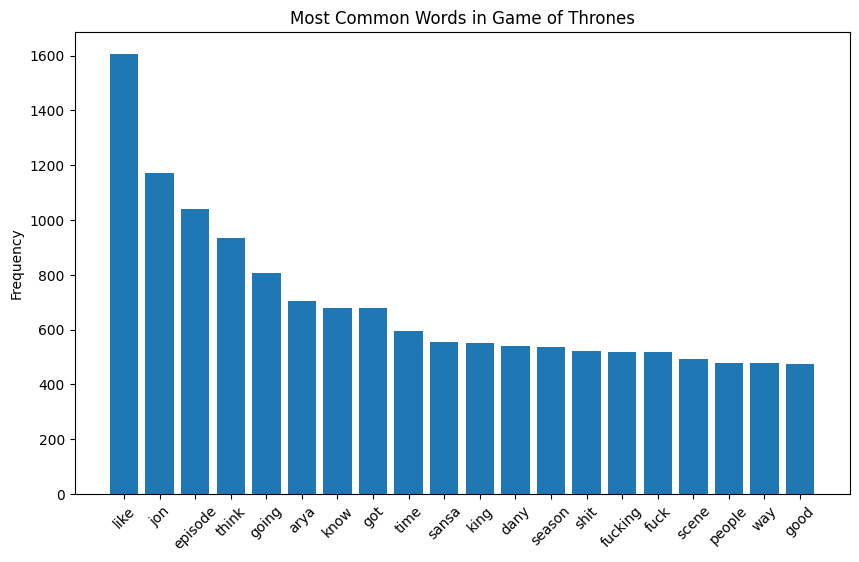

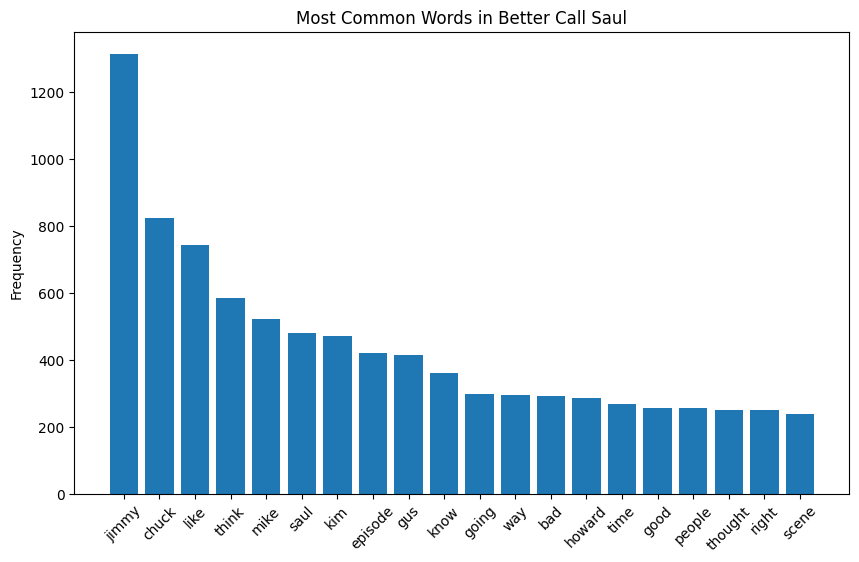

In [149]:
import string 
from collections import Counter

# Create bar charts for the most common words in each serie
def plot_most_common_words(posts, title, n=20):
    words = posts.split()
    words = [word for word in words if len(word) > 1 and word not in string.punctuation]
    word_counts = Counter(words)
    most_common = word_counts.most_common(n)
    
    words, counts = zip(*most_common)
    
    plt.figure(figsize=(10, 6))
    plt.bar(words, counts)
    plt.xticks(rotation=45)
    plt.title(f'Most Common Words in {title}')
    plt.ylabel('Frequency')
    plt.show()

# Join the cleaned posts for each show
posts_got_no_stop = ' '.join(df1[df1['title'] == 'Game of Thrones']['post_no_stop'].tolist())
posts_bcs_no_stop = ' '.join(df1[df1['title'] == 'Better Call Saul']['post_no_stop'].tolist())

# Remove all punctuation (including dots, commas, etc.) from the joined posts
posts_got_no_stop = posts_got_no_stop.translate(str.maketrans('', '', string.punctuation))
posts_bcs_no_stop = posts_bcs_no_stop.translate(str.maketrans('', '', string.punctuation))

plot_most_common_words(posts_got_no_stop, 'Game of Thrones')
plot_most_common_words(posts_bcs_no_stop, 'Better Call Saul')






In [ ]:
# Perform topic modeling by using BERTopic - Separately for each show
# NOTE: Re-running the topic modeling can sometimes produce different topics and associated words.

from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction import text

# ---------------------------------- GAME OF THRONES ----------------------------------
print("="*60)
print("ANALYZING GAME OF THRONES")
print("="*60)

# Filter for Game of Thrones (2017)
df_got = df1[(df1['title'] == 'Game of Thrones') & (df1['year'] == 2017)].copy()
texts_got = df_got['post_no_stop'].tolist()

print(f"Game of Thrones posts: {len(df_got)}")

# Keep character names in topics for character development analysis
vectorizer_got = CountVectorizer(
    min_df=2,
    max_df=0.7,
    ngram_range=(1, 2)
)
# top_n_words increased to 20 to capture more character names
# calculate_probabilities set to True to get topic probabilities
# Add character names to the vectorizer's vocabulary to ensure they are included in topics
# min_topic_size set to 50 due to smaller dataset
# nr_topics set to 5 for better topic distribution, as larger topics looked too similar and overlap
topic_model_got = BERTopic(
    language='english',
    top_n_words=20,
    calculate_probabilities=True,
    vectorizer_model=vectorizer_got,
    min_topic_size=50,
    nr_topics=5
)

topics_got, probs_got = topic_model_got.fit_transform(texts_got)
df_got['topic'] = topics_got

print("\nGame of Thrones - Topic Information:")
print(topic_model_got.get_topic_info())

# ---------------------------------- BETTER CALL SAUL ----------------------------------
print("\n" + "="*60)
print("ANALYZING BETTER CALL SAUL")
print("="*60)

# Filter for Better Call Saul (2020)
df_bcs = df1[(df1['title'] == 'Better Call Saul') & (df1['year'] == 2020)].copy()
texts_bcs = df_bcs['post_no_stop'].tolist()

print(f"Better Call Saul posts: {len(df_bcs)}")

# Add character names to the vectorizer's vocabulary to ensure they are included in topics
bcs_characters = ['jimmy', 'kim', 'saul', 'goodman', 'mike', 'nacho', 'chuck', 'howard', 'lalo', 'gus', 
                  'fring', 'gustavo', 'hector', 'salamanca', 'erin', 'francesca', 'wexler', 'mcgill',
                  'tuco', 'huell', 'kuby', 'schweikart', 'mesa', 'hamlin', 'hhm', 'ernesto',
                  'irene', 'clifford', 'rich', 'paige', 'kevin', 'acker', 'domingo', 'krazy']

vectorizer_bcs = CountVectorizer(
    min_df=2,
    max_df=0.7,
    ngram_range=(1, 2)
)

# top_n_words increased to 20 to capture more character names
# calculate_probabilities set to True to get topic probabilities
# Add character names to the vectorizer's vocabulary to ensure they are included in topics
# min_topic_size set to 50 due to smaller dataset
# nr_topics set to 5 for better topic distribution, as larger topics looked too similar and overlap
topic_model_bcs = BERTopic(
    top_n_words=20,
    calculate_probabilities=True,
    vectorizer_model=vectorizer_bcs,
    min_topic_size=50,  
    nr_topics=5
)

topics_bcs, probs_bcs = topic_model_bcs.fit_transform(texts_bcs)
df_bcs['topic'] = topics_bcs

print("\nBetter Call Saul - Topic Information:")
print(topic_model_bcs.get_topic_info())

# ---------------------------------- SAVE RESULTS TO CSV ----------------------------------
print("\n" + "="*60)
print("SAVING RESULTS")
print("="*60)

# Save dataframes with topics
df_got.to_csv('BERTopic_GameOfThrones_2017.csv', index=False)
print(f"Saved: BERTopic_GameOfThrones_2017.csv ({len(df_got)} posts)")

df_bcs.to_csv('BERTopic_BetterCallSaul_2020.csv', index=False)
print(f"Saved: BERTopic_BetterCallSaul_2020.csv ({len(df_bcs)} posts)")

# Save topic information separately for easy reference
topic_info_got = topic_model_got.get_topic_info()
topic_info_got.to_csv('BERTopic_GameOfThrones_Topics.csv', index=False)
print(f"Saved: BERTopic_GameOfThrones_Topics.csv ({len(topic_info_got)} topics)")

topic_info_bcs = topic_model_bcs.get_topic_info()
topic_info_bcs.to_csv('BERTopic_BetterCallSaul_Topics.csv', index=False)
print(f"Saved: BERTopic_BetterCallSaul_Topics.csv ({len(topic_info_bcs)} topics)")

print("\nAll files saved successfully!")


ANALYZING GAME OF THRONES
Game of Thrones posts: 3805

Game of Thrones - Topic Information:
   Topic  Count                                       Name  \
0     -1   1611               -1_dragon_night_wall_tormund   
1      0   1385                  0_arya_dany_cersei_dragon   
2      1    440                 1_dickon_rickon_dick_bronn   
3      2    307            2_gilly_episodes_series_writing   
4      3     62  3_littlefinger_finger_little finger_chess   

                                                                                                                                                                                          Representation  \
0                                       [dragon, night, wall, tormund, night king, dany, blue, davos, fire, hound, white, landing, dragons, rock, wight, jorah, ice, cleganebowl, dragonstone, viserion]   
1                                                [arya, dany, cersei, dragon, jaime, tyrion, euron, gendry, drogon, jamie, drag

In [161]:
# Get BERT topics from the file -- Game of Thrones

df_gos_topics = pd.read_csv('BERTopic_GameOfThrones_Topics.csv')
display(df_gos_topics)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,1611,-1_dragon_night_wall_tormund,"['dragon', 'night', 'wall', 'tormund', 'night king', 'dany', 'blue', 'davos', 'fire', 'hound', 'white', 'landing', 'dragons', 'rock', 'wight', 'jorah', 'ice', 'cleganebowl', 'dragonstone', 'viserion']","['westoros avengers assembled - jon , jorah , gendry , tormund , beric , thoros hound . time lay beating white walkers', 'danny dragons : mach 1.95 assume : arrow rock 26 miles ( marathon ) n eastwatch . boys capture wight midday gendry runs 5 hour marathon , arrives dusk ( evidence : lighting davos picks ) . raven flies overnight 2x normal speed ( 100 miles hour ) , arriving 15 hours later ( 50 mph raven speed : internet . 1500 miles king landing wall ; dragonstone eastwatch latitude , dragonstone king landing longitude ) . boys hold day , ice freezing 3 "" depth ( assume wind , 0deg ambient temperature , 34deg water temperature , chart 1 : ) builds danny 1 hour cover 1500 miles dragon . : dragons travel mach 1.95 .', 'yeah , mind time skips kind annoyed people saying getting x y fast stupid , time skips fuck sake , episode ... bad . mean , going generous , lets suicide squad walking day , met bears , fought bears , camped night , went wandering morning , gendry probably started run afternoon , night time running mm .. maybe . lets takes raven hours fly eastwatch dragonstone probably shorter dragon fly dragonstone north wall daenerys reached suicide squad , probably dusk , days shorter winter , probably . thin ice .']"
1,0,1385,0_arya_dany_cersei_dragon,"['arya', 'dany', 'cersei', 'dragon', 'jaime', 'tyrion', 'euron', 'gendry', 'drogon', 'jamie', 'dragons', 'littlefinger', 'sand', 'rhaegar', 'nymeria', 'night', 'army', 'wall', 'north', 'ice']","['great , arya _ _ favorite sibling .', 'fuck arya', 'bran warging arya wearing face . mindfuck']"
2,1,440,1_dickon_rickon_dick_bronn,"['dickon', 'rickon', 'dick', 'bronn', 'thank', 'sorry', 'ha', 'laugh', 'internet', 'holy fuck', 'oh shit', 'nice', 'emotions', 'crying', 'yup', 'think actually', 'comment', 'hard', 'forgot', 'hot']","['dickon', '* dickon *', 'dickon die battle ?']"
3,2,307,2_gilly_episodes_series_writing,"['gilly', 'episodes', 'series', 'writing', 'citadel', 'battle scene', 'ending', 'seasons', 'incredible', 'leaked', 'great episode', 'worst', 'character', 'song', 'tv', 'episode season', 'hbo', 'miss', 'credits', 'important']","['gilly fucking cute .', 'bastard bros . sortof ( thanks gilly ... ) .', 'mad hell shortest episode series . 7 episodes .']"
4,3,62,3_littlefinger_finger_little finger_chess,"['littlefinger', 'finger', 'little finger', 'chess', 'ladder', 'plant', 'littlefinger die', 'afraid', 'faceless man', 'bum', 'chaos ladder', 'sweet', 'faceless', 'hate', 'theory', 'varys', 'raven', 'north', 'necessary', 'true parentage']","['texas law hawk swooped save littlefinger', 'fucking littlefinger', 'let hype let forget littlefinger master creeps .']"


In [162]:
df_gos_2017 = pd.read_csv('BERTopic_GameOfThrones_2017.csv')

# Show the first 5 rows of Topic 0 for analysis
display(df_gos_2017[df_gos_2017['topic'] == 0].head(-5))

,title,type,year,post,post_clean,post_no_stop,topic
5,Game of Thrones,linear,2017,Scene from next episode: Theon floating on his driftwood when suddenly he hears a splash in the water. He looks and can barely see a small boat approaching him through the thick fog. The boat stops before Theon when a young man lends out a hand to help him into the boat. Theon rolls over onto the floor of the small boat and looks up at the young man. It's Gendry and he's here to take the Iron Throne.,scene from next episode: theon floating on his driftwood when suddenly he hears a splash in the water. he looks and can barely see a small boat approaching him through the thick fog. the boat stops before theon when a young man lends out a hand to help him into the boat. theon rolls over onto the floor of the small boat and looks up at the young man. it's gendry and he's here to take the iron throne.,scene episode : theon floating driftwood suddenly hears splash water . looks barely small boat approaching thick fog . boat stops theon young man lends hand help boat . theon rolls floor small boat looks young man . gendry iron throne .,0
6,Game of Thrones,linear,2017,I want someone to look at me the way that Jon looks at 'Rows for Days' Gendry.,i want someone to look at me the way that jon looks at 'rows for days' gendry.,want look way jon looks ' rows days ' gendry .,0
7,Game of Thrones,linear,2017,"You were expecting Tyrion, but it was me, Olenna!","you were expecting tyrion, but it was me, olenna!","expecting tyrion , , olenna !",0
9,Game of Thrones,linear,2017,Browne vs Arya is a perfect reason why dex builds can be far more superior in dark souls 3,browne vs arya is a perfect reason why dex builds can be far more superior in dark souls 3,browne vs arya perfect reason dex builds far superior dark souls 3,0
11,Game of Thrones,linear,2017,Well Missandei pointed out that Jon wouldn't be considered a bastard in Naath and since he's the son of Rheagar he'd be first in line of succession,well missandei pointed out that jon wouldn't be considered a bastard in naath and since he's the son of rheagar he'd be first in line of succession,missandei pointed jon considered bastard naath son rheagar line succession,0
...,...,...,...,...,...,...,...
3770,Game of Thrones,linear,2017,That scene where Arya is taking in her surroundings makes me realize how emotionally invested in this show I am.,that scene where arya is taking in her surroundings makes me realize how emotionally invested in this show i am.,scene arya taking surroundings makes realize emotionally invested .,0
3773,Game of Thrones,linear,2017,"Cersei is 100% marrying the Night King, calling it right now","cersei is 100% marrying the night king, calling it right now","cersei 100 % marrying night king , calling right",0
3785,Game of Thrones,linear,2017,To be fair as far as we know it means nothing to him other than a story of a dead prince. IIRC He has no reason to believe that Ned is not Jons father.,to be fair as far as we know it means nothing to him other than a story of a dead prince. iirc he has no reason to believe that ned is not jons father.,fair far know means story dead prince . iirc reason believe ned jons father .,0
3790,Game of Thrones,linear,2017,Did Jon bend the knee for Dany? cause the previews shows she's on the winterfell.,did jon bend the knee for dany? cause the previews shows she's on the winterfell.,jon bend knee dany ? cause previews shows winterfell .,0


In [163]:
df_gos_2017 = pd.read_csv('BERTopic_GameOfThrones_2017.csv')

# Show the first 5 rows of Topic 0 for analysis
display(df_gos_2017[df_gos_2017['topic'] == 1].head(-5))

,title,type,year,post,post_clean,post_no_stop,topic
4,Game of Thrones,linear,2017,"Oh not at all, she is fucking fine.","oh not at all, she is fucking fine.","oh , fucking fine .",1
10,Game of Thrones,linear,2017,I had this exact same thought,i had this exact same thought,exact thought,1
17,Game of Thrones,linear,2017,She's been saying that since they've been together.,she's been saying that since they've been together.,saying .,1
33,Game of Thrones,linear,2017,Thank you very much!,thank you very much!,thank !,1
34,Game of Thrones,linear,2017,Oh shit...,oh shit...,oh shit ...,1
...,...,...,...,...,...,...,...
3760,Game of Thrones,linear,2017,Yeah fair point haha. I also think he felt that he had served his purpose and was ready to go,yeah fair point haha. i also think he felt that he had served his purpose and was ready to go,yeah fair point haha . think felt served purpose ready,1
3765,Game of Thrones,linear,2017,"I'm a dumb, I don't get it. What am I missing?","i'm a dumb, i don't get it. what am i missing?","dumb , . missing ?",1
3767,Game of Thrones,linear,2017,"Dickon really grew on me this episode. Well, I guess he's dead now.","dickon really grew on me this episode. well, i guess he's dead now.","dickon grew episode . , guess dead .",1
3772,Game of Thrones,linear,2017,But there is!,but there is!,!,1


In [164]:
df_gos_2017 = pd.read_csv('BERTopic_GameOfThrones_2017.csv')

# Show the first 5 rows of Topic 0 for analysis
display(df_gos_2017[df_gos_2017['topic'] == 2].head(-5))

,title,type,year,post,post_clean,post_no_stop,topic
1,Game of Thrones,linear,2017,At least it would be a reason for Samwell to poke around in there ( ͡° ͜ʖ ͡°),at least it would be a reason for samwell to poke around in there ( ͡° ͜ʖ ͡°),reason samwell poke ( ͡ ° ͜ʖ ͡ ° ),2
12,Game of Thrones,linear,2017,"Billy Bones shows up and we're treated to our first GOT sea battle, coincidence? I think not.","billy bones shows up and we're treated to our first got sea battle, coincidence? i think not.","billy bones shows treated got sea battle , coincidence ? think .",2
53,Game of Thrones,linear,2017,I'm finding myself cheering Sam on more and more every time!,i'm finding myself cheering sam on more and more every time!,finding cheering sam time !,2
54,Game of Thrones,linear,2017,I think the fact that it gave you goose bumps might mean that it wasn't trash writing.,i think the fact that it gave you goose bumps might mean that it wasn't trash writing.,think fact gave goose bumps mean trash writing .,2
93,Game of Thrones,linear,2017,"I'm not joking when I say this, this episode literally gave me an anxiety attack.","i'm not joking when i say this, this episode literally gave me an anxiety attack.","joking , episode literally gave anxiety attack .",2
...,...,...,...,...,...,...,...
3677,Game of Thrones,linear,2017,"Gilly: ""Steps Sam.. No. Shits, steps"" \n\n","gilly: ""steps sam.. no. shits, steps""","gilly : "" steps sam .. . shits , steps """,2
3687,Game of Thrones,linear,2017,I love how Gilly didn't give a fuck he is losing his mind lol,i love how gilly didn't give a fuck he is losing his mind lol,love gilly fuck losing mind lol,2
3697,Game of Thrones,linear,2017,"What an absolutely breathtaking battle. The lighting, editing, and atmosphere were perfect. Euron is getting better with every scene, he was perfectly unhinged. Seeing Theon's PTSD relapse was a great emotional anchor, and it's really what holds the scene together because no one is invested in the Sand Sneks. I'm excited to see where Theon goes from here, now that he's been stripped of his only close relation.","what an absolutely breathtaking battle. the lighting, editing, and atmosphere were perfect. euron is getting better with every scene, he was perfectly unhinged. seeing theon's ptsd relapse was a great emotional anchor, and it's really what holds the scene together because no one is invested in the sand sneks. i'm excited to see where theon goes from here, now that he's been stripped of his only close relation.","absolutely breathtaking battle . lighting , editing , atmosphere perfect . euron getting better scene , perfectly unhinged . seeing theon ptsd relapse great emotional anchor , holds scene invested sand sneks . excited theon goes , stripped close relation .",2
3713,Game of Thrones,linear,2017,"Got his sword, his family, and his woman. Even Sam is Eggs friend rather than his.","got his sword, his family, and his woman. even sam is eggs friend rather than his.","got sword , family , woman . sam eggs friend .",2


In [165]:
# Get BERT topics from the file -- Better Call Saul

df_bcs_topics = pd.read_csv('BERTopic_BetterCallSaul_Topics.csv')
display(df_bcs_topics)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,646,-1_bb_money_desert_lalo,"['bb', 'money', 'desert', 'lalo', 'nacho', 'little', 'kaylee', 'old', 'shot', 'madrigal', 'watch', 'tuco', 'jesse', 'saying', 'lawyer', 'family', 'new', 'chuck', 'happened', 'trying']","['spoiler warning maniac seen bb', 'fucking walt lol . ruin bb universes life .... maybe skinny pete badger', 'dumb . showed thinking loud scenes jimmy lalo said loud meeting . rest inferred subtext . knows stakes dealing cartel warns jimmy wants danger . willing risk life safety . assuring , returns . character willing risk life hours later . unbeknownst , worked , drive super long ( jimmy leave way early , showered night cooked big dinner arrive middle 9 ) . lalo gave directions meeting ( likely happened earlier 9 ) followed road jimmy mike walking taking care guy hunting . rescued saved hike . changing perspective , prioritized life , able live knowing man loved , yes wrong . dumb .']"
1,0,308,0_breaking bad_breaking_bcs_bb,"['breaking bad', 'breaking', 'bcs', 'bb', 'episodes', 'goodman', 'shot', 'getting', 'best', 'saul goodman', 'new', 'better saul', 'shit', 'middle', 'seasons', 'plot', 'vince', 'shows', 'action', 'game']","['getting good literally forget prequel breaking bad . stand awesome thought walt jesse reason liked bb place thought interesting heavily invested season 1 . crazy . wonder s significance kim having middle court house ? "" hm middle "" comment like mean . stupid know means missed .', '"" de "" means "" "" = george goodman "" george "" characters bb bcs ?', 'easy forget actual prime , creators game new breaking bad saga content , solely engaging awesome right montage start crazy song people crazy shit ‘ 50 percent off!% ’ truly gave breaking bad feels .']"
2,1,109,1_lalo_nacho_jail_want,"['lalo', 'nacho', 'jail', 'want', 'fring', 'breaking', 'breaking bad', 'hector', 'dea', 'pollos', 'location', 'salamanca', 'money', 'los', 'domingo', 'crazy', 'story', 'business', 'pollos hermanos', 'plan']","['folded 8s lalo .', 'lalo going soon .', 'gus plotter . going mind lalo ? big !']"
3,2,85,2_omg_reply_applies_hey,"['omg', 'reply', 'applies', 'hey', 'best', 'cheers', 'yeah true', 'survive oh', 'add', 'example', 'upvote', 'til', 'laughed', 'commenter', 'username', 'definition', 'lately', 'lazy', 'laughed hard', 'successful']","['omg , definitely', 'omg amazing .', 'hey thanks chill forth commenter online today . like seeing threads reddit lately people cool turn argument ad hominem . cheers']"
4,3,74,3_chuck_offer_feels_bowling balls,"['chuck', 'offer', 'feels', 'bowling balls', 'bowling', 'plate', 'genuine', 'hhm', 'sees', 'balls', 'like howard', 'trying', 'brother', 'guilt', 'years', 'death', 'chuck death', 'seeing howard', 'namaste', 'offered']","['jimmy certainly jealous howard . sees howard weak mark , chuck puppet basically . jimmy sees hhm constrictive work environment zero room original creative thought , exactly like d&m , delighted freed prison . "" genuine "" hug license plate , felt cringe - worthy saul . think jimmy resents howard effort sort therapy pawn . pretty sure saul guilt chuck death , grief brother words , things prefers private .', 'disgusting blaming chuck feel righteous', 'nt , literally knows chuck actually blocking , howard feelings']"


I looked into the csv file to get a overall impression for each topic and decided that number of topics of 3 should have been better as topics still overlap somehow.

In [166]:
# Get posts based on topic ID for analysis (game of thrones)
df_got_2017 = pd.read_csv('BERTopic_GameOfThrones_2017.csv')
display(df_got_2017.head(5))

# Filter by topic ID
df_got_topic_0 = df_got_2017[df_got_2017['topic'] == 0]
display(df_got_topic_0)

df_got_topic_minus1 = df_got_2017[df_got_2017['topic'] == -1]
display(df_got_topic_minus1)

,title,type,year,post,post_clean,post_no_stop,topic
0,Game of Thrones,linear,2017,LITTLEFINGER IS FUCKING DEAD UPVOTE PARTY,littlefinger is fucking dead upvote party,littlefinger fucking dead upvote party,3
1,Game of Thrones,linear,2017,At least it would be a reason for Samwell to poke around in there ( ͡° ͜ʖ ͡°),at least it would be a reason for samwell to poke around in there ( ͡° ͜ʖ ͡°),reason samwell poke ( ͡ ° ͜ʖ ͡ ° ),2
2,Game of Thrones,linear,2017,Plot armor op please nerf.,plot armor op please nerf.,plot armor op nerf .,-1
3,Game of Thrones,linear,2017,Who's the big woman? Brienne?,who's the big woman? brienne?,big woman ? brienne ?,-1
4,Game of Thrones,linear,2017,"Oh not at all, she is fucking fine.","oh not at all, she is fucking fine.","oh , fucking fine .",1


,title,type,year,post,post_clean,post_no_stop,topic
5,Game of Thrones,linear,2017,Scene from next episode: Theon floating on his driftwood when suddenly he hears a splash in the water. He looks and can barely see a small boat approaching him through the thick fog. The boat stops before Theon when a young man lends out a hand to help him into the boat. Theon rolls over onto the floor of the small boat and looks up at the young man. It's Gendry and he's here to take the Iron Throne.,scene from next episode: theon floating on his driftwood when suddenly he hears a splash in the water. he looks and can barely see a small boat approaching him through the thick fog. the boat stops before theon when a young man lends out a hand to help him into the boat. theon rolls over onto the floor of the small boat and looks up at the young man. it's gendry and he's here to take the iron throne.,scene episode : theon floating driftwood suddenly hears splash water . looks barely small boat approaching thick fog . boat stops theon young man lends hand help boat . theon rolls floor small boat looks young man . gendry iron throne .,0
6,Game of Thrones,linear,2017,I want someone to look at me the way that Jon looks at 'Rows for Days' Gendry.,i want someone to look at me the way that jon looks at 'rows for days' gendry.,want look way jon looks ' rows days ' gendry .,0
7,Game of Thrones,linear,2017,"You were expecting Tyrion, but it was me, Olenna!","you were expecting tyrion, but it was me, olenna!","expecting tyrion , , olenna !",0
9,Game of Thrones,linear,2017,Browne vs Arya is a perfect reason why dex builds can be far more superior in dark souls 3,browne vs arya is a perfect reason why dex builds can be far more superior in dark souls 3,browne vs arya perfect reason dex builds far superior dark souls 3,0
11,Game of Thrones,linear,2017,Well Missandei pointed out that Jon wouldn't be considered a bastard in Naath and since he's the son of Rheagar he'd be first in line of succession,well missandei pointed out that jon wouldn't be considered a bastard in naath and since he's the son of rheagar he'd be first in line of succession,missandei pointed jon considered bastard naath son rheagar line succession,0
...,...,...,...,...,...,...,...
3793,Game of Thrones,linear,2017,Gendry the forgotten for several seasons and forced into the spotlight at this late hour Waters,gendry the forgotten for several seasons and forced into the spotlight at this late hour waters,gendry forgotten seasons forced spotlight late hour waters,0
3795,Game of Thrones,linear,2017,"Glad to finally get the chance to talk about this one...\n\nIn short, Spectacle saved this episode, the dragons, Night King, and some of the early banter between the seven.\n\nDiscounting those three things, this is the worst episode in the show's entire run.\n\nThe writing here is stunningly bad in places.\n\nThe Legwork needed to get the dragons on the scene was fucking absurd. Gendry sprints all the way back to Eastwatch a raven is sent the 1000+ miles from Eastwatch to Dragonstone,, received, and then the Dragons leave, and arrive at the wall in what? A day? Less? not only does it go massively against the established pace of events like these, but it dissolves tension... why should we fear the WW when Dany can cover near the ENITRETY of westeros that quickly?\n\n""Oh no, the Wights are attacking Winterfell and Bear Island at the same time!""\n""Oh wait, no, Dany showed up at both in a few hours and drove both hordes off...""\n\nArya going full psychopath right the FUCK OUT OF NOWHERE,with next to no build-up or lead-in that wasn't atrociously contrived, all to continue this already dragged out plotline of Arya and Sansa mistrusting each other that we KNOW is going to end with LF's death.... at this point all we're doing is muddying Sansa's characterisation and BUTCHERING Arya's....\n\nOne of the main points of her character over the last two seasons is seeing the grey, she didn't kill Lady Crane becaus

,title,type,year,post,post_clean,post_no_stop,topic
2,Game of Thrones,linear,2017,Plot armor op please nerf.,plot armor op please nerf.,plot armor op nerf .,-1
3,Game of Thrones,linear,2017,Who's the big woman? Brienne?,who's the big woman? brienne?,big woman ? brienne ?,-1
8,Game of Thrones,linear,2017,"""Davos the Manos"" \n\nBrilliant","""davos the manos"" brilliant",""" davos manos "" brilliant",-1
16,Game of Thrones,linear,2017,Not their best effort but Davos had one hell of an episode tonight.,not their best effort but davos had one hell of an episode tonight.,best effort davos hell episode tonight .,-1
18,Game of Thrones,linear,2017,"""There always lessons in failures.""\n\n""Yes, you must be very wise by now.""\n\nQueen of Thorns till the bitter end...","""there always lessons in failures."" ""yes, you must be very wise by now."" queen of thorns till the bitter end...",""" lessons failures . "" "" yes , wise . "" queen thorns till bitter end ...",-1
...,...,...,...,...,...,...,...
3782,Game of Thrones,linear,2017,Do you mean Craster?,do you mean craster?,mean craster ?,-1
3792,Game of Thrones,linear,2017,s e x,s e x,s e x,-1
3796,Game of Thrones,linear,2017,"No, it wasn't. It was abrupt and stupid. LF barely got any face time. That whole Winterfell plot was as shitty as the Dorne coup.","no, it wasn't. it was abrupt and stupid. lf barely got any face time. that whole winterfell plot was as shitty as the dorne coup.",", . abrupt stupid . lf barely got face time . winterfell plot shitty dorne coup .",-1
3797,Game of Thrones,linear,2017,"I don't think it's how long it'll take to kill but for how long she'll have to watch the body rot. Kinda fucked up, but last week there were theories that harkened back to Ned's father and brother's deaths that would've been really brutal","i don't think it's how long it'll take to kill but for how long she'll have to watch the body rot. kinda fucked up, but last week there were theories that harkened back to ned's father and brother's deaths that would've been really brutal","think long kill long watch body rot . kinda fucked , week theories harkened ned father brother deaths brutal",-1


In [167]:
# Filter by topic ID
df_got_topic_0 = df_got_2017[df_got_2017['topic'] == 1]
display(df_got_topic_0)

df_got_topic_minus1 = df_got_2017[df_got_2017['topic'] == 2]
display(df_got_topic_minus1)

,title,type,year,post,post_clean,post_no_stop,topic
4,Game of Thrones,linear,2017,"Oh not at all, she is fucking fine.","oh not at all, she is fucking fine.","oh , fucking fine .",1
10,Game of Thrones,linear,2017,I had this exact same thought,i had this exact same thought,exact thought,1
17,Game of Thrones,linear,2017,She's been saying that since they've been together.,she's been saying that since they've been together.,saying .,1
33,Game of Thrones,linear,2017,Thank you very much!,thank you very much!,thank !,1
34,Game of Thrones,linear,2017,Oh shit...,oh shit...,oh shit ...,1
...,...,...,...,...,...,...,...
3783,Game of Thrones,linear,2017,you gotta own it,you gotta own it,got ta,1
3787,Game of Thrones,linear,2017,Or Ghost...,or ghost...,ghost ...,1
3794,Game of Thrones,linear,2017,*Golden prosthetic dick...,*golden prosthetic dick...,* golden prosthetic dick ...,1
3798,Game of Thrones,linear,2017,RIP Dickon Jokes 2017-2017,rip dickon jokes 2017-2017,rip dickon jokes 2017 - 2017,1


,title,type,year,post,post_clean,post_no_stop,topic
1,Game of Thrones,linear,2017,At least it would be a reason for Samwell to poke around in there ( ͡° ͜ʖ ͡°),at least it would be a reason for samwell to poke around in there ( ͡° ͜ʖ ͡°),reason samwell poke ( ͡ ° ͜ʖ ͡ ° ),2
12,Game of Thrones,linear,2017,"Billy Bones shows up and we're treated to our first GOT sea battle, coincidence? I think not.","billy bones shows up and we're treated to our first got sea battle, coincidence? i think not.","billy bones shows treated got sea battle , coincidence ? think .",2
53,Game of Thrones,linear,2017,I'm finding myself cheering Sam on more and more every time!,i'm finding myself cheering sam on more and more every time!,finding cheering sam time !,2
54,Game of Thrones,linear,2017,I think the fact that it gave you goose bumps might mean that it wasn't trash writing.,i think the fact that it gave you goose bumps might mean that it wasn't trash writing.,think fact gave goose bumps mean trash writing .,2
93,Game of Thrones,linear,2017,"I'm not joking when I say this, this episode literally gave me an anxiety attack.","i'm not joking when i say this, this episode literally gave me an anxiety attack.","joking , episode literally gave anxiety attack .",2
...,...,...,...,...,...,...,...
3784,Game of Thrones,linear,2017,"Yeah, I thought the editing was awful. Very cheesy fight scene editing.","yeah, i thought the editing was awful. very cheesy fight scene editing.","yeah , thought editing awful . cheesy fight scene editing .",2
3786,Game of Thrones,linear,2017,Next episode​ he'll be a Brony,next episode​ he'll be a brony,episode​ brony,2
3788,Game of Thrones,linear,2017,Holy shit. Just rewinded ant this definitely happened.,holy shit. just rewinded ant this definitely happened.,holy shit . rewinded ant definitely happened .,2
3789,Game of Thrones,linear,2017,That's a really sneaky way of rewarding Sam without explicitly saying it so that no one who's listening would know that he approves of Sam and that Sam has those scrolls,that's a really sneaky way of rewarding sam without explicitly saying it so that no one who's listening would know that he approves of sam and that sam has those scrolls,sneaky way rewarding sam explicitly saying listening know approves sam sam scrolls,2


In [168]:
df_got_topic_0 = df_got_2017[df_got_2017['topic'] == 1]
display(df_got_topic_0)

df_got_topic_minus1 = df_got_2017[df_got_2017['topic'] == 2]
display(df_got_topic_minus1)

,title,type,year,post,post_clean,post_no_stop,topic
4,Game of Thrones,linear,2017,"Oh not at all, she is fucking fine.","oh not at all, she is fucking fine.","oh , fucking fine .",1
10,Game of Thrones,linear,2017,I had this exact same thought,i had this exact same thought,exact thought,1
17,Game of Thrones,linear,2017,She's been saying that since they've been together.,she's been saying that since they've been together.,saying .,1
33,Game of Thrones,linear,2017,Thank you very much!,thank you very much!,thank !,1
34,Game of Thrones,linear,2017,Oh shit...,oh shit...,oh shit ...,1
...,...,...,...,...,...,...,...
3783,Game of Thrones,linear,2017,you gotta own it,you gotta own it,got ta,1
3787,Game of Thrones,linear,2017,Or Ghost...,or ghost...,ghost ...,1
3794,Game of Thrones,linear,2017,*Golden prosthetic dick...,*golden prosthetic dick...,* golden prosthetic dick ...,1
3798,Game of Thrones,linear,2017,RIP Dickon Jokes 2017-2017,rip dickon jokes 2017-2017,rip dickon jokes 2017 - 2017,1


,title,type,year,post,post_clean,post_no_stop,topic
1,Game of Thrones,linear,2017,At least it would be a reason for Samwell to poke around in there ( ͡° ͜ʖ ͡°),at least it would be a reason for samwell to poke around in there ( ͡° ͜ʖ ͡°),reason samwell poke ( ͡ ° ͜ʖ ͡ ° ),2
12,Game of Thrones,linear,2017,"Billy Bones shows up and we're treated to our first GOT sea battle, coincidence? I think not.","billy bones shows up and we're treated to our first got sea battle, coincidence? i think not.","billy bones shows treated got sea battle , coincidence ? think .",2
53,Game of Thrones,linear,2017,I'm finding myself cheering Sam on more and more every time!,i'm finding myself cheering sam on more and more every time!,finding cheering sam time !,2
54,Game of Thrones,linear,2017,I think the fact that it gave you goose bumps might mean that it wasn't trash writing.,i think the fact that it gave you goose bumps might mean that it wasn't trash writing.,think fact gave goose bumps mean trash writing .,2
93,Game of Thrones,linear,2017,"I'm not joking when I say this, this episode literally gave me an anxiety attack.","i'm not joking when i say this, this episode literally gave me an anxiety attack.","joking , episode literally gave anxiety attack .",2
...,...,...,...,...,...,...,...
3784,Game of Thrones,linear,2017,"Yeah, I thought the editing was awful. Very cheesy fight scene editing.","yeah, i thought the editing was awful. very cheesy fight scene editing.","yeah , thought editing awful . cheesy fight scene editing .",2
3786,Game of Thrones,linear,2017,Next episode​ he'll be a Brony,next episode​ he'll be a brony,episode​ brony,2
3788,Game of Thrones,linear,2017,Holy shit. Just rewinded ant this definitely happened.,holy shit. just rewinded ant this definitely happened.,holy shit . rewinded ant definitely happened .,2
3789,Game of Thrones,linear,2017,That's a really sneaky way of rewarding Sam without explicitly saying it so that no one who's listening would know that he approves of Sam and that Sam has those scrolls,that's a really sneaky way of rewarding sam without explicitly saying it so that no one who's listening would know that he approves of sam and that sam has those scrolls,sneaky way rewarding sam explicitly saying listening know approves sam sam scrolls,2
